<a href="https://colab.research.google.com/github/jonabersaesime/ACTIVIDAD_5_IA/blob/main/Actividad_6_PLN_y_VC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TECMILENIO MASTER en IA, PLN y VC
#Actividad 6
#Detección y correspondencia de puntos de interés con SIFT, rotación y transformación afín con RANSAC
#Jonathan Daniel Bernal Sanchez



Saving ImagenAct6.jpg to ImagenAct6 (1).jpg


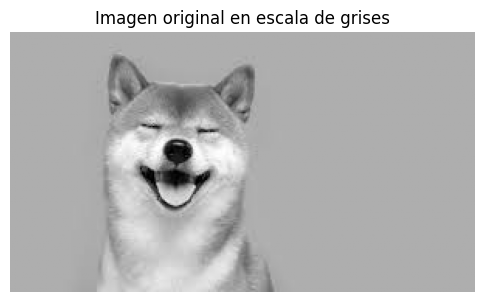

Dimensiones de la imagen: (168, 300)
Tipo de dato: uint8


In [ ]:
# ==========================================
# PUNTO 1. Cargar una imagen en escala de grises
# ==========================================

#Sube tu imagen (.jpg, .jpeg o .png)
from google.colab import files
uploaded = files.upload()

# Importamos librerías necesarias
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Obtenemos el nombre del archivo cargado
image_path = list(uploaded.keys())[0]

# Leemos la imagen en escala de grises
img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Verificamos que la imagen se haya cargado correctamente
if img_gray is None:
    raise ValueError("No se pudo cargar la imagen. Verifica que sea .jpg, .jpeg o .png")

# Mostramos la imagen
plt.figure(figsize=(6,6))
plt.imshow(img_gray, cmap='gray')
plt.title("Imagen original en escala de grises")
plt.axis("off")
plt.show()

# Imprimimos información básica
print("Dimensiones de la imagen:", img_gray.shape)
print("Tipo de dato:", img_gray.dtype)

Imagen cargada correctamente.
Dimensiones de la imagen: (168, 300)
Valor mínimo de intensidad: 0
Valor máximo de intensidad: 255


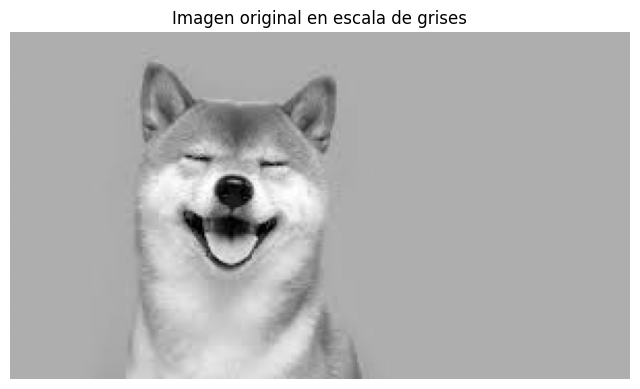

Número total de puntos de interés detectados: 102


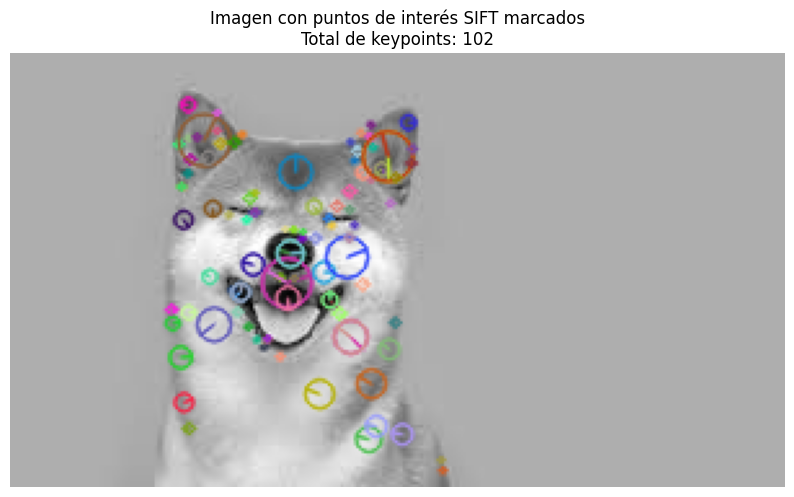


Ejemplo de algunos puntos de interés detectados:

Punto 1:
  Coordenadas (x, y): (62.13331604003906, 99.05294036865234)
  Escala (size): 4.066930770874023
  Orientación (angle): 353.8946838378906
  Respuesta del detector: 0.017905114218592644
----------------------------------------
Punto 2:
  Coordenadas (x, y): (62.55683898925781, 104.29385375976562)
  Escala (size): 5.09122896194458
  Orientación (angle): 351.5108947753906
  Respuesta del detector: 0.01880086027085781
----------------------------------------
Punto 3:
  Coordenadas (x, y): (64.92082977294922, 35.185768127441406)
  Escala (size): 3.4914023876190186
  Orientación (angle): 176.11900329589844
  Respuesta del detector: 0.020377157256007195
----------------------------------------
Punto 4:
  Coordenadas (x, y): (65.6492691040039, 117.47232818603516)
  Escala (size): 8.438051223754883
  Orientación (angle): 354.30059814453125
  Respuesta del detector: 0.0153211560100317
----------------------------------------
Punto 5:
  C

In [ ]:
# ==========================================
# PUNTO 2. EXTRAER Y MOSTRAR LOS PUNTOS DE INTERÉS SIFT
# ==========================================

# --------------------------------------------------
# 1) IMPORTAR LIBRERÍAS NECESARIAS
# --------------------------------------------------
# cv2: para procesamiento de imágenes con OpenCV
# numpy: para manejo de arreglos
# matplotlib: para visualizar imágenes dentro de Colab
import cv2
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# 2) VERIFICAR QUE LA IMAGEN YA ESTÉ CARGADA
# --------------------------------------------------
# Este punto asume que en el punto 1 ya cargaste una imagen
# en escala de grises y la guardaste en la variable img_gray.
#
# Si img_gray no existe o está vacía, este bloque marcará error.
try:
    img_gray
except NameError:
    raise ValueError("La variable 'img_gray' no existe. Primero debes cargar la imagen en escala de grises en el punto 1.")


# --------------------------------------------------
# 3) COMPROBAR QUE LA IMAGEN SÍ CONTIENE INFORMACIÓN
# --------------------------------------------------
# Esto ayuda a detectar si la imagen no se cargó correctamente.
if img_gray is None:
    raise ValueError("La imagen no se cargó correctamente. Revisa el punto 1.")

# Mostramos información básica para comprobar que la imagen sí existe
print("Imagen cargada correctamente.")
print("Dimensiones de la imagen:", img_gray.shape)
print("Valor mínimo de intensidad:", img_gray.min())
print("Valor máximo de intensidad:", img_gray.max())


# --------------------------------------------------
# 4) MOSTRAR LA IMAGEN ORIGINAL EN ESCALA DE GRISES
# --------------------------------------------------
# Antes de detectar puntos, mostramos la imagen original
# para confirmar que sí se ve correctamente.
plt.figure(figsize=(8, 8))
plt.imshow(img_gray, cmap='gray')
plt.title("Imagen original en escala de grises")
plt.axis("off")
plt.show()


# --------------------------------------------------
# 5) CREAR EL DETECTOR SIFT
# --------------------------------------------------
# SIFT detecta puntos clave y calcula descriptores.
# Si esta línea da error en Colab, instala antes:
# !pip install opencv-contrib-python --quiet
sift = cv2.SIFT_create()


# --------------------------------------------------
# 6) DETECTAR LOS PUNTOS DE INTERÉS Y DESCRIPTORES
# --------------------------------------------------
# detectAndCompute hace dos cosas:
# - detecta los keypoints (puntos de interés)
# - calcula los descriptores de cada punto
keypoints1, descriptors1 = sift.detectAndCompute(img_gray, None)


# --------------------------------------------------
# 7) IMPRIMIR CUÁNTOS PUNTOS DE INTERÉS SE DETECTARON
# --------------------------------------------------
print("Número total de puntos de interés detectados:", len(keypoints1))


# --------------------------------------------------
# 8) DIBUJAR LOS PUNTOS DE INTERÉS SOBRE LA IMAGEN
# --------------------------------------------------
# cv2.drawKeypoints permite dibujar los puntos encontrados.
#
# La bandera DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS hace que:
# - el tamaño del círculo represente la escala del punto
# - una pequeña línea indique su orientación
#
# IMPORTANTE:
# Como la imagen original está en escala de grises, primero la
# convertimos a una imagen BGR para que OpenCV pueda dibujar
# los puntos de forma visible.
img_gray_bgr = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)

img_sift_marked = cv2.drawKeypoints(
    img_gray_bgr,                      # imagen base donde se van a dibujar los puntos
    keypoints1,                        # lista de keypoints detectados
    None,                              # imagen de salida (None = OpenCV crea una nueva)
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)


# --------------------------------------------------
# 9) CONVERTIR LA IMAGEN A RGB PARA MOSTRARLA EN MATPLOTLIB
# --------------------------------------------------
# OpenCV trabaja normalmente en BGR, pero matplotlib usa RGB.
# Si no se convierte, los colores pueden verse mal.
img_sift_marked_rgb = cv2.cvtColor(img_sift_marked, cv2.COLOR_BGR2RGB)


# --------------------------------------------------
# 10) MOSTRAR LA IMAGEN CON LOS PUNTOS DE INTERÉS MARCADOS
# --------------------------------------------------
plt.figure(figsize=(10, 10))
plt.imshow(img_sift_marked_rgb)
plt.title(f"Imagen con puntos de interés SIFT marcados\nTotal de keypoints: {len(keypoints1)}")
plt.axis("off")
plt.show()


# --------------------------------------------------
# 11) MOSTRAR EJEMPLOS DE ALGUNOS PUNTOS DETECTADOS
# --------------------------------------------------
# Esto sirve para evidenciar que cada keypoint tiene:
# - posición
# - escala
# - orientación
print("\nEjemplo de algunos puntos de interés detectados:\n")

num_ejemplos = min(10, len(keypoints1))  # mostrar hasta 10 ejemplos

for i in range(num_ejemplos):
    kp = keypoints1[i]
    print(f"Punto {i+1}:")
    print(f"  Coordenadas (x, y): {kp.pt}")
    print(f"  Escala (size): {kp.size}")
    print(f"  Orientación (angle): {kp.angle}")
    print(f"  Respuesta del detector: {kp.response}")
    print("-" * 40)

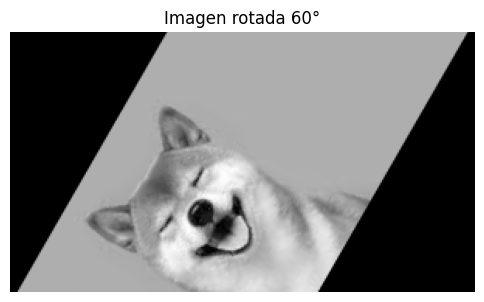

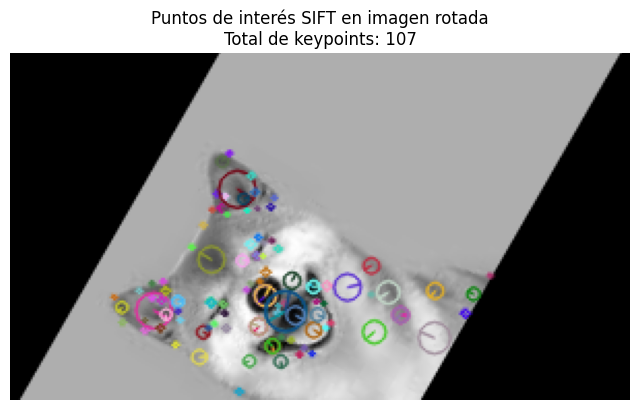

Ejemplos de keypoints detectados en la imagen rotada:
Keypoint 1:
  Coordenadas (x, y): (50.060665130615234, 117.94157409667969)
  Escala (size): 2.206202983856201
  Orientación (angle): 221.22219848632812
  Respuesta: 0.014397231861948967
----------------------------------------
Keypoint 2:
  Coordenadas (x, y): (53.66452407836914, 122.79548645019531)
  Escala (size): 5.375606060028076
  Orientación (angle): 132.18955993652344
  Respuesta: 0.03810429573059082
----------------------------------------
Keypoint 3:
  Coordenadas (x, y): (54.0490837097168, 129.93133544921875)
  Escala (size): 2.86962628364563
  Orientación (angle): 125.83587646484375
  Respuesta: 0.014074040576815605
----------------------------------------
Keypoint 4:
  Coordenadas (x, y): (62.07402038574219, 114.78253936767578)
  Escala (size): 2.3692567348480225
  Orientación (angle): 257.32275390625
  Respuesta: 0.02047184482216835
----------------------------------------
Keypoint 5:
  Coordenadas (x, y): (64.804412841

In [ ]:
# ==========================================
# PUNTO 3. Girar la imagen 60° con warpAffine
# y detectar nuevamente keypoints SIFT
# ==========================================

# Obtenemos dimensiones de la imagen
h, w = img_gray.shape

# Definimos el centro de rotación
center = (w // 2, h // 2)

# Ángulo de rotación
angle = 60

# Escala de la transformación (1.0 = sin cambio de tamaño)
scale = 1.0

# Calculamos la matriz de rotación 2x3
rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)

# Aplicamos la transformación afín
img_rotated = cv2.warpAffine(img_gray, rotation_matrix, (w, h))

# Mostramos la imagen rotada
plt.figure(figsize=(6,6))
plt.imshow(img_rotated, cmap='gray')
plt.title("Imagen rotada 60°")
plt.axis("off")
plt.show()

# Detectamos keypoints y descriptores en la imagen rotada
keypoints2, descriptors2 = sift.detectAndCompute(img_rotated, None)

# Dibujamos keypoints sobre la imagen rotada
img_sift_2 = cv2.drawKeypoints(
    img_rotated,
    keypoints2,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Mostramos los keypoints de la imagen rotada
plt.figure(figsize=(8,8))
plt.imshow(img_sift_2, cmap='gray')
plt.title(f"Puntos de interés SIFT en imagen rotada\nTotal de keypoints: {len(keypoints2)}")
plt.axis("off")
plt.show()

# Mostramos algunos keypoints como ejemplo
print("Ejemplos de keypoints detectados en la imagen rotada:")
for i, kp in enumerate(keypoints2[:10]):
    print(f"Keypoint {i+1}:")
    print(f"  Coordenadas (x, y): {kp.pt}")
    print(f"  Escala (size): {kp.size}")
    print(f"  Orientación (angle): {kp.angle}")
    print(f"  Respuesta: {kp.response}")
    print("-" * 40)

Total de coincidencias encontradas (knn): 102
Coincidencias buenas después de la prueba de proporción: 66


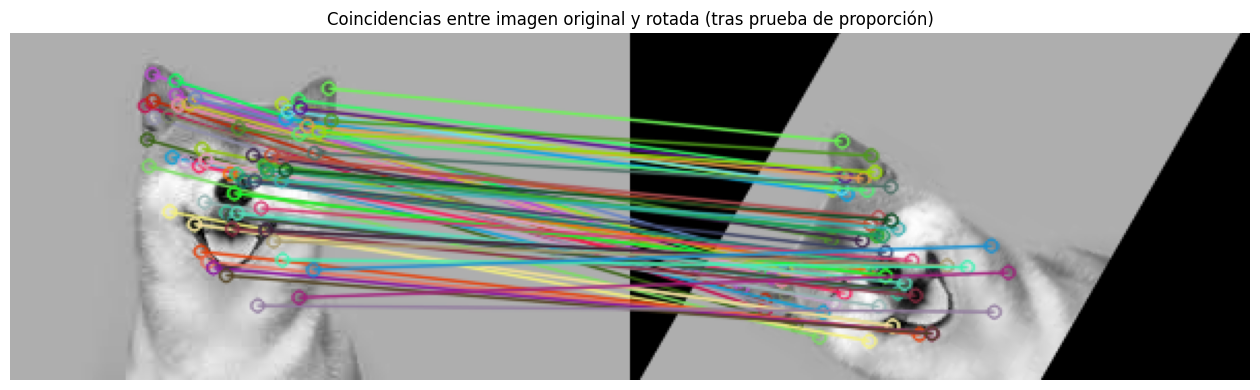

In [ ]:
# ==========================================
# PUNTO 4. Hacer correspondencias entre la imagen original
# y la imagen rotada, aplicando la prueba de proporción
# ==========================================

# Creamos el comparador BFMatcher
# Para SIFT se suele usar norma L2
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# Buscamos los 2 mejores vecinos más cercanos para cada descriptor
matches_knn = bf.knnMatch(descriptors1, descriptors2, k=2)

# Aplicamos la prueba de proporción de Lowe
good_matches = []
ratio_threshold = 0.75  # valor típico recomendado

for m, n in matches_knn:
    if m.distance < ratio_threshold * n.distance:
        good_matches.append(m)

print("Total de coincidencias encontradas (knn):", len(matches_knn))
print("Coincidencias buenas después de la prueba de proporción:", len(good_matches))

# Dibujamos las coincidencias buenas con líneas
img_matches = cv2.drawMatches(
    img_gray, keypoints1,
    img_rotated, keypoints2,
    good_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16,8))
plt.imshow(img_matches)
plt.title("Coincidencias entre imagen original y rotada (tras prueba de proporción)")
plt.axis("off")
plt.show()

Cantidad de coincidencias buenas disponibles: 66
Forma de pts_original: (66, 1, 2)
Forma de pts_rotated : (66, 1, 2)

Matriz afín estimada con RANSAC:
[[  0.4996392   -0.86495221 148.01263117]
 [  0.86495221   0.4996392  -87.86338149]]

Resumen de RANSAC:
Coincidencias buenas antes de RANSAC: 66
Inliers aceptados por RANSAC:         64
Outliers rechazados por RANSAC:       2


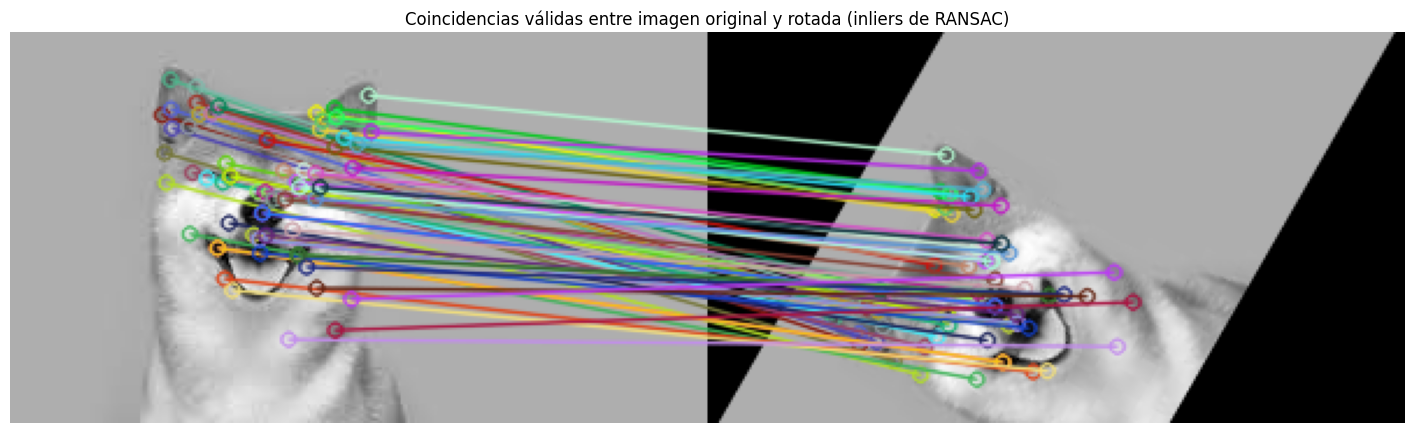

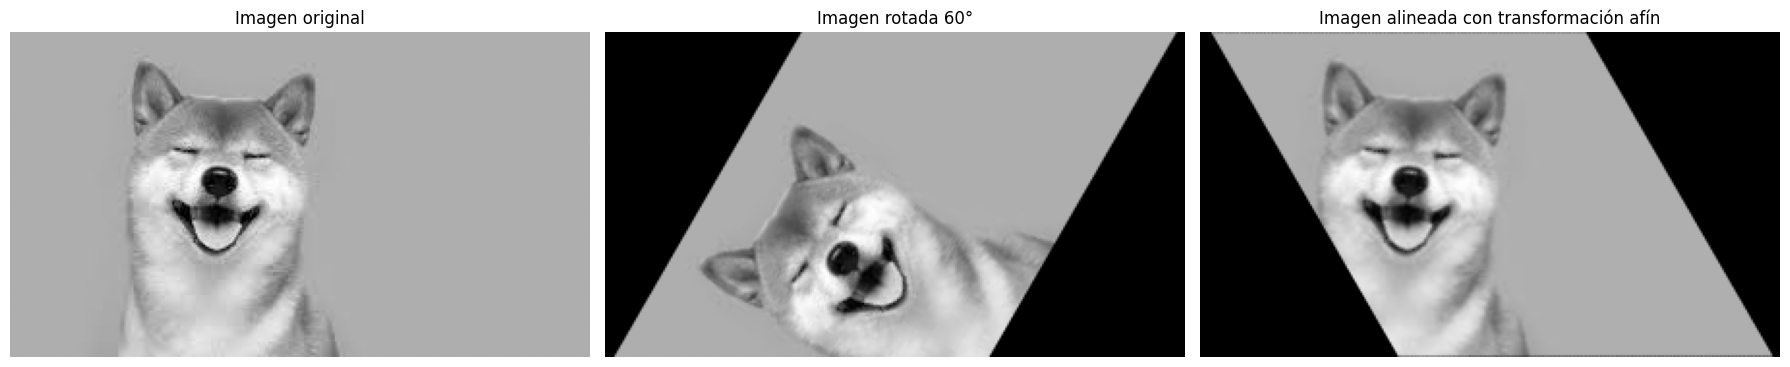

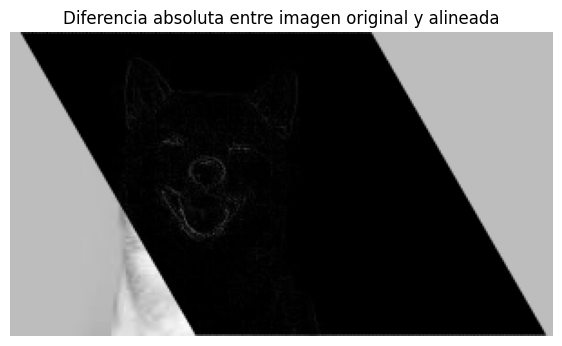


Error medio absoluto entre imagen original y alineada: 63.2845


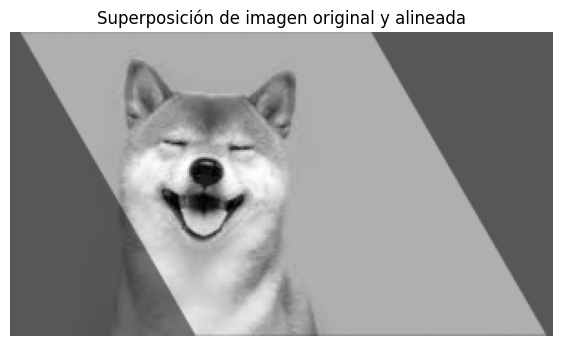


Ángulo aproximado recuperado por la transformación: -59.99 grados


In [ ]:
# ==========================================
# PUNTO 5. TRANSFORMACIÓN AFÍN CON RANSAC
# ==========================================
# Objetivo:
# Encontrar una transformación afín que permita mapear
# la imagen rotada hacia la imagen original, usando
# únicamente coincidencias confiables entre puntos SIFT.
#
# Este código:
# 1) valida coincidencias
# 2) extrae coordenadas correspondientes
# 3) estima la transformación afín con RANSAC
# 4) separa inliers y outliers
# 5) alinea la imagen rotada
# 6) muestra resultados visuales
# 7) calcula una métrica simple de error
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# SECCIÓN 1. VALIDAR QUE EXISTAN COINCIDENCIAS SUFICIENTES
# --------------------------------------------------
# Para estimar una transformación afín se requieren
# al menos 3 pares de puntos correspondientes.

if len(good_matches) < 3:
    raise ValueError(
        "No hay suficientes coincidencias buenas para estimar una transformación afín. "
        "Se necesitan al menos 3."
    )

print("Cantidad de coincidencias buenas disponibles:", len(good_matches))


# --------------------------------------------------
# SECCIÓN 2. EXTRAER LOS PUNTOS CORRESPONDIENTES
# --------------------------------------------------
# Se construyen dos arreglos de puntos:
# - pts_original: coordenadas en la imagen original
# - pts_rotated: coordenadas en la imagen rotada
#
# queryIdx -> índice del punto en la imagen original
# trainIdx -> índice del punto en la imagen rotada

pts_original = np.float32([
    keypoints1[m.queryIdx].pt for m in good_matches
]).reshape(-1, 1, 2)

pts_rotated = np.float32([
    keypoints2[m.trainIdx].pt for m in good_matches
]).reshape(-1, 1, 2)

print("Forma de pts_original:", pts_original.shape)
print("Forma de pts_rotated :", pts_rotated.shape)


# --------------------------------------------------
# SECCIÓN 3. ESTIMAR LA TRANSFORMACIÓN AFÍN CON RANSAC
# --------------------------------------------------
# estimateAffinePartial2D busca una transformación afín parcial:
# - traslación
# - rotación
# - escalado uniforme
#
# method=cv2.RANSAC permite ignorar coincidencias incorrectas.

affine_matrix, inliers_mask = cv2.estimateAffinePartial2D(
    pts_rotated,                  # puntos fuente: imagen rotada
    pts_original,                 # puntos destino: imagen original
    method=cv2.RANSAC,            # método robusto
    ransacReprojThreshold=3.0,    # umbral de error permitido
    maxIters=3000,                # máximo número de iteraciones
    confidence=0.99,              # nivel de confianza
    refineIters=20                # refinamiento final
)

# Verificar que sí se haya encontrado una solución válida
if affine_matrix is None:
    raise ValueError("No fue posible estimar una transformación afín válida con RANSAC.")

print("\nMatriz afín estimada con RANSAC:")
print(affine_matrix)


# --------------------------------------------------
# SECCIÓN 4. ANALIZAR LOS INLIERS Y OUTLIERS
# --------------------------------------------------
# RANSAC devuelve una máscara donde:
# 1 = coincidencia aceptada (inlier)
# 0 = coincidencia rechazada (outlier)

inliers_mask = inliers_mask.ravel().astype(bool)

num_matches = len(good_matches)
num_inliers = np.sum(inliers_mask)
num_outliers = num_matches - num_inliers

print("\nResumen de RANSAC:")
print(f"Coincidencias buenas antes de RANSAC: {num_matches}")
print(f"Inliers aceptados por RANSAC:         {num_inliers}")
print(f"Outliers rechazados por RANSAC:       {num_outliers}")


# --------------------------------------------------
# SECCIÓN 5. SEPARAR LAS COINCIDENCIAS VÁLIDAS
# --------------------------------------------------
# Nos quedamos solamente con las coincidencias que
# sí son consistentes con la transformación estimada.

inlier_matches = [
    match for i, match in enumerate(good_matches) if inliers_mask[i]
]


# --------------------------------------------------
# SECCIÓN 6. DIBUJAR SOLO LOS INLIERS
# --------------------------------------------------
# Se muestran únicamente las coincidencias que RANSAC
# consideró correctas.

img_inliers = cv2.drawMatches(
    img_gray, keypoints1,
    img_rotated, keypoints2,
    inlier_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(18, 8))
plt.imshow(img_inliers)
plt.title("Coincidencias válidas entre imagen original y rotada (inliers de RANSAC)")
plt.axis("off")
plt.show()


# --------------------------------------------------
# SECCIÓN 7. ALINEAR LA IMAGEN ROTADA
# --------------------------------------------------
# Se aplica la matriz afín estimada para transformar
# la imagen rotada y tratar de alinearla con la original.

h, w = img_gray.shape

img_aligned = cv2.warpAffine(
    img_rotated,          # imagen que se quiere transformar
    affine_matrix,        # matriz afín calculada
    (w, h)                # tamaño de salida
)


# --------------------------------------------------
# SECCIÓN 8. MOSTRAR ORIGINAL, ROTADA Y ALINEADA
# --------------------------------------------------
# Esta comparación permite evaluar visualmente si
# la transformación funcionó correctamente.

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_rotated, cmap='gray')
plt.title("Imagen rotada 60°")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_aligned, cmap='gray')
plt.title("Imagen alineada con transformación afín")
plt.axis("off")

plt.tight_layout()
plt.show()


# --------------------------------------------------
# SECCIÓN 9. CALCULAR DIFERENCIA ABSOLUTA
# --------------------------------------------------
# Se calcula la diferencia pixel a pixel entre la
# imagen original y la imagen alineada.
# Si la alineación es buena, la diferencia tenderá
# a ser menor en la mayoría de las regiones.

difference = cv2.absdiff(img_gray, img_aligned)

plt.figure(figsize=(7, 7))
plt.imshow(difference, cmap='gray')
plt.title("Diferencia absoluta entre imagen original y alineada")
plt.axis("off")
plt.show()


# --------------------------------------------------
# SECCIÓN 10. CALCULAR UNA MÉTRICA SIMPLE DE ERROR
# --------------------------------------------------
# Se usa el error medio absoluto para tener una medida
# numérica sencilla de la calidad de la alineación.

mean_error = np.mean(difference)
print(f"\nError medio absoluto entre imagen original y alineada: {mean_error:.4f}")


# --------------------------------------------------
# SECCIÓN 11. SUPERPOSICIÓN DE IMÁGENES
# --------------------------------------------------
# Esta visualización mezcla la imagen original con la
# alineada para ver si ambas coinciden correctamente.

overlay = cv2.addWeighted(img_gray, 0.5, img_aligned, 0.5, 0)

plt.figure(figsize=(7, 7))
plt.imshow(overlay, cmap='gray')
plt.title("Superposición de imagen original y alineada")
plt.axis("off")
plt.show()


# --------------------------------------------------
# SECCIÓN 12. ESTIMAR EL ÁNGULO RECUPERADO (OPCIONAL)
# --------------------------------------------------
# A partir de la matriz afín se puede obtener una
# aproximación del ángulo de rotación estimado.

a = affine_matrix[0, 0]
b = affine_matrix[0, 1]

estimated_angle_rad = np.arctan2(b, a)
estimated_angle_deg = np.degrees(estimated_angle_rad)

print(f"\nÁngulo aproximado recuperado por la transformación: {estimated_angle_deg:.2f} grados")